In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)

n_samples = 1000
date_range = pd.date_range(start='2021-01-01', periods=n_samples, freq='D')

data = {
    'Date': date_range,
    'PM2.5': np.random.normal(50, 20, n_samples).clip(0, 500),
    'PM10': np.random.normal(80, 30, n_samples).clip(0, 600),
    'NO2': np.random.normal(40, 15, n_samples).clip(0, 200),
    'SO2': np.random.normal(15, 8, n_samples).clip(0, 100),
    'CO': np.random.normal(1.5, 0.5, n_samples).clip(0, 10),
    'O3': np.random.normal(60, 25, n_samples).clip(0, 300),
    'Temperature': np.random.normal(25, 8, n_samples),
    'Humidity': np.random.normal(60, 20, n_samples).clip(0, 100),
    'Wind_Speed': np.random.normal(10, 5, n_samples).clip(0, 50)
}

df = pd.DataFrame(data)

df['AQI'] = (
    0.4 * df['PM2.5'] +
    0.3 * df['PM10'] +
    0.15 * df['NO2'] +
    0.1 * df['SO2'] +
    0.05 * df['O3'] +
    np.random.normal(0, 10, n_samples)
).clip(0, 500)

df['AQI_Category'] = pd.cut(df['AQI'],
                             bins=[0, 50, 100, 150, 200, 300, 500],
                             labels=['Good', 'Moderate', 'Unhealthy for Sensitive',
                                   'Unhealthy', 'Very Unhealthy', 'Hazardous'])

print("\nDataset created successfully")
print("Dataset shape:", df.shape)
print("\nFive rows:")
print(df.head())


Dataset created successfully
Dataset shape: (1000, 12)

Five rows:
        Date      PM2.5        PM10        NO2        SO2        CO  \
0 2021-01-01  59.934283  121.980663  29.872326   0.000000  1.068253   
1 2021-01-02  47.234714  107.739010  37.832220   8.116920  1.484398   
2 2021-01-03  62.953771   81.788911  28.113701  11.691156  1.509008   
3 2021-01-04  80.460597   60.591897  35.380577  30.101501  1.736315   
4 2021-01-05  45.316933  100.946699  11.595780  19.452425  0.816571   

          O3  Temperature   Humidity  Wind_Speed        AQI AQI_Category  
0  49.406008    16.087349  75.703702    9.834874  75.173083     Moderate  
1  48.664647    19.952553  24.446381    7.481749  70.869473     Moderate  
2  15.108921    17.463519  74.294913    9.138125  60.846698     Moderate  
3  51.747745    20.616033  55.325519   13.573659  41.841455         Good  
4  78.320727    23.286798  74.149154   16.389283  54.457204     Moderate  


In [3]:
print("\nSource: Simulated Environmental Monitoring Data")
print("Domain: Air Quality and Environmental Health")

print("\nNumber of Records:", len(df))
print("Number of Features:", len(df.columns) - 1)
print("Time Period:", df['Date'].min(), "to", df['Date'].max())

print("\nFeature Types:")
print("- Time Series: Date")
print("- Numerical Features: PM2.5, PM10, NO2, SO2, CO, O3")
print("- Meteorological Features: Temperature, Humidity, Wind_Speed")
print("- Target Variable: AQI (continuous - regression problem)")

print("\nTarget Variable Statistics:")
print(df['AQI'].describe())

print("\nAQI Category Distribution:")
print(df['AQI_Category'].value_counts())


Source: Simulated Environmental Monitoring Data
Domain: Air Quality and Environmental Health

Number of Records: 1000
Number of Features: 11
Time Period: 2021-01-01 00:00:00 to 2023-09-27 00:00:00

Feature Types:
- Time Series: Date
- Numerical Features: PM2.5, PM10, NO2, SO2, CO, O3
- Meteorological Features: Temperature, Humidity, Wind_Speed
- Target Variable: AQI (continuous - regression problem)

Target Variable Statistics:
count    1000.000000
mean       55.145426
std        15.619363
min         4.448309
25%        44.546351
50%        54.825384
75%        65.771780
max       110.371138
Name: AQI, dtype: float64

AQI Category Distribution:
AQI_Category
Moderate                   621
Good                       378
Unhealthy for Sensitive      1
Unhealthy                    0
Very Unhealthy               0
Hazardous                    0
Name: count, dtype: int64


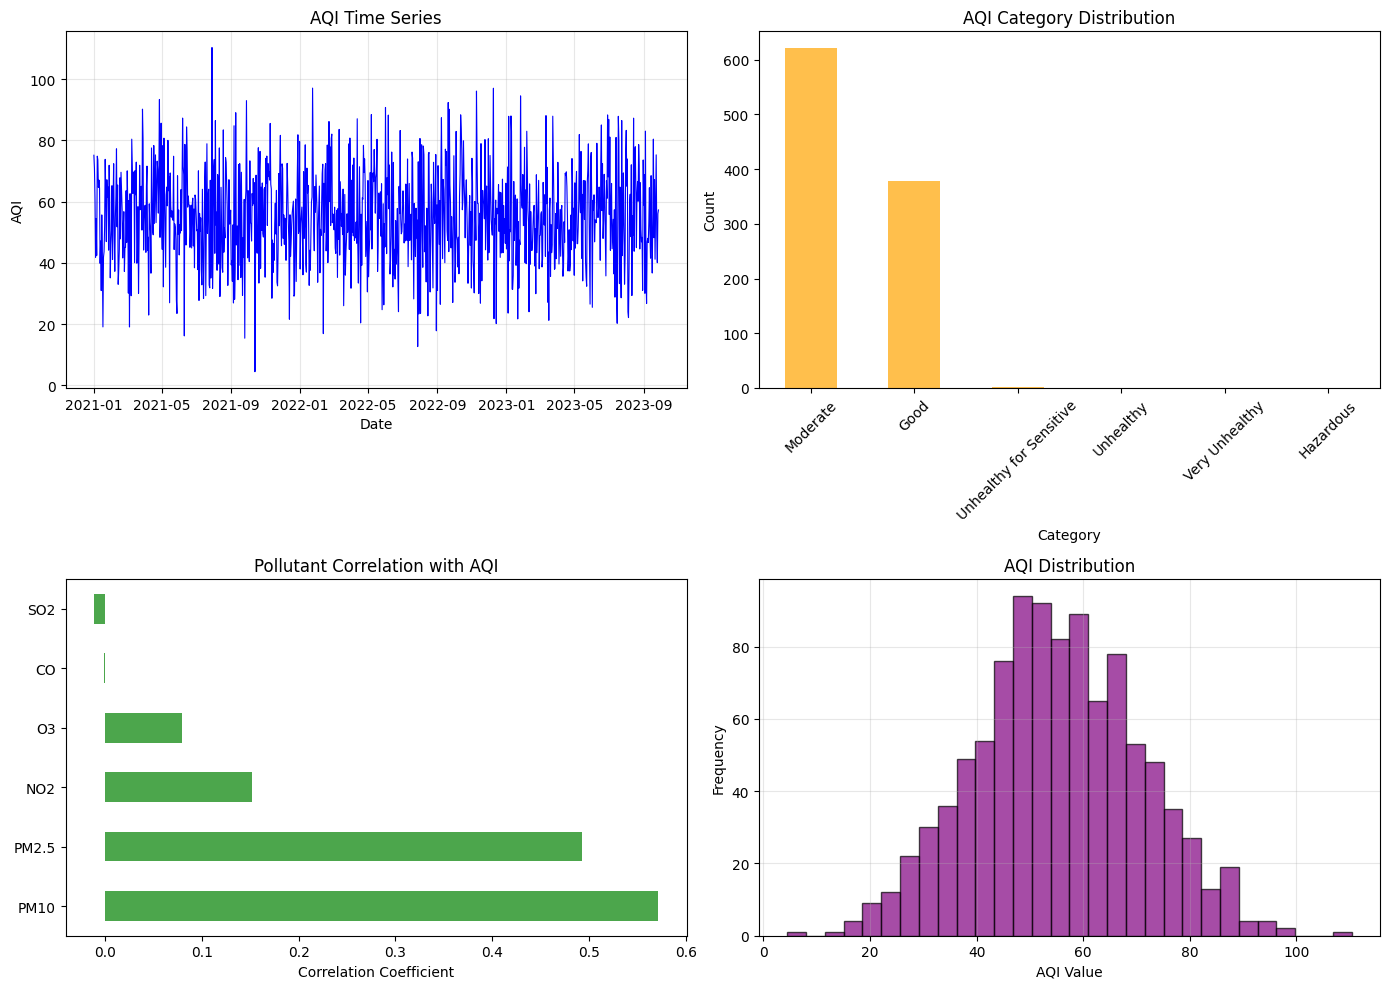

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df['Date'], df['AQI'], linewidth=0.8, color='blue')
axes[0, 0].set_title('AQI Time Series', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('AQI')
axes[0, 0].grid(True, alpha=0.3)

df['AQI_Category'].value_counts().plot(kind='bar', ax=axes[0, 1], color='orange', alpha=0.7)
axes[0, 1].set_title('AQI Category Distribution', fontsize=12)
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
correlation = df[pollutants + ['AQI']].corr()['AQI'].drop('AQI').sort_values(ascending=False)
correlation.plot(kind='barh', ax=axes[1, 0], color='green', alpha=0.7)
axes[1, 0].set_title('Pollutant Correlation with AQI', fontsize=12)
axes[1, 0].set_xlabel('Correlation Coefficient')

axes[1, 1].hist(df['AQI'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('AQI Distribution', fontsize=12)
axes[1, 1].set_xlabel('AQI Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
print("\nChecking for missing values:")
print(df.isnull().sum())

missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing percentage:")
print(missing_percentage[missing_percentage > 0])

if df.isnull().sum().sum() > 0:
    df = df.fillna(method='ffill')
    print("\nMissing values handled using forward fill")
else:
    print("\nNo missing values found")


Checking for missing values:
Date            0
PM2.5           0
PM10            0
NO2             0
SO2             0
CO              0
O3              0
Temperature     0
Humidity        0
Wind_Speed      0
AQI             0
AQI_Category    0
dtype: int64

Missing percentage:
Series([], dtype: float64)

No missing values found


In [6]:
print("Feature Engineeering")
df['AQI_lag_1'] = df['AQI'].shift(1)
df['AQI_lag_2'] = df['AQI'].shift(2)
df['AQI_lag_7'] = df['AQI'].shift(7)
df['AQI_rolling_mean_7'] = df['AQI'].rolling(window=7).mean()
df['AQI_rolling_std_7'] = df['AQI'].rolling(window=7).std()

df['PM2.5_lag_1'] = df['PM2.5'].shift(1)
df['PM10_lag_1'] = df['PM10'].shift(1)

df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Day_of_Year'] = df['Date'].dt.dayofyear

df = df.dropna()
print("Lag features created:")
print("-AQI lag features: 1 day, 2 days, 7 days")
print("-Rolling statistics: 7-day mean and std")
print("-Pollutant lag features")
print("-Temporal features: Day of week, Month, Day of year")

print("\nDataset shape after feature engineering:", df.shape)
print("\nNew features:")
print(df.columns.tolist())

Feature Engineeering
Lag features created:
-AQI lag features: 1 day, 2 days, 7 days
-Rolling statistics: 7-day mean and std
-Pollutant lag features
-Temporal features: Day of week, Month, Day of year

Dataset shape after feature engineering: (993, 22)

New features:
['Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind_Speed', 'AQI', 'AQI_Category', 'AQI_lag_1', 'AQI_lag_2', 'AQI_lag_7', 'AQI_rolling_mean_7', 'AQI_rolling_std_7', 'PM2.5_lag_1', 'PM10_lag_1', 'Day_of_Week', 'Month', 'Day_of_Year']


In [7]:
feature_columns = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
                   'Temperature', 'Humidity', 'Wind_Speed',
                   'AQI_lag_1', 'AQI_lag_2', 'AQI_lag_7',
                   'AQI_rolling_mean_7', 'AQI_rolling_std_7',
                   'PM2.5_lag_1', 'PM10_lag_1',
                   'Day_of_Week', 'Month', 'Day_of_Year']
X = df[feature_columns]
y = df['AQI']
print("Features selected:", len(feature_columns))
print("Target variable: AQI")
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Features selected: 19
Target variable: AQI

Feature matrix shape: (993, 19)
Target vector shape: (993,)


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_columns, index=X.index)
print("\nFeatures normalized using StandardScaler")
print("Mean of scaled features:", X_scaled.mean().mean())
print("Std of scaled features:", X_scaled.std().mean())


Features normalized using StandardScaler
Mean of scaled features: 2.4102790633723646e-17
Std of scaled features: 1.00050390529779


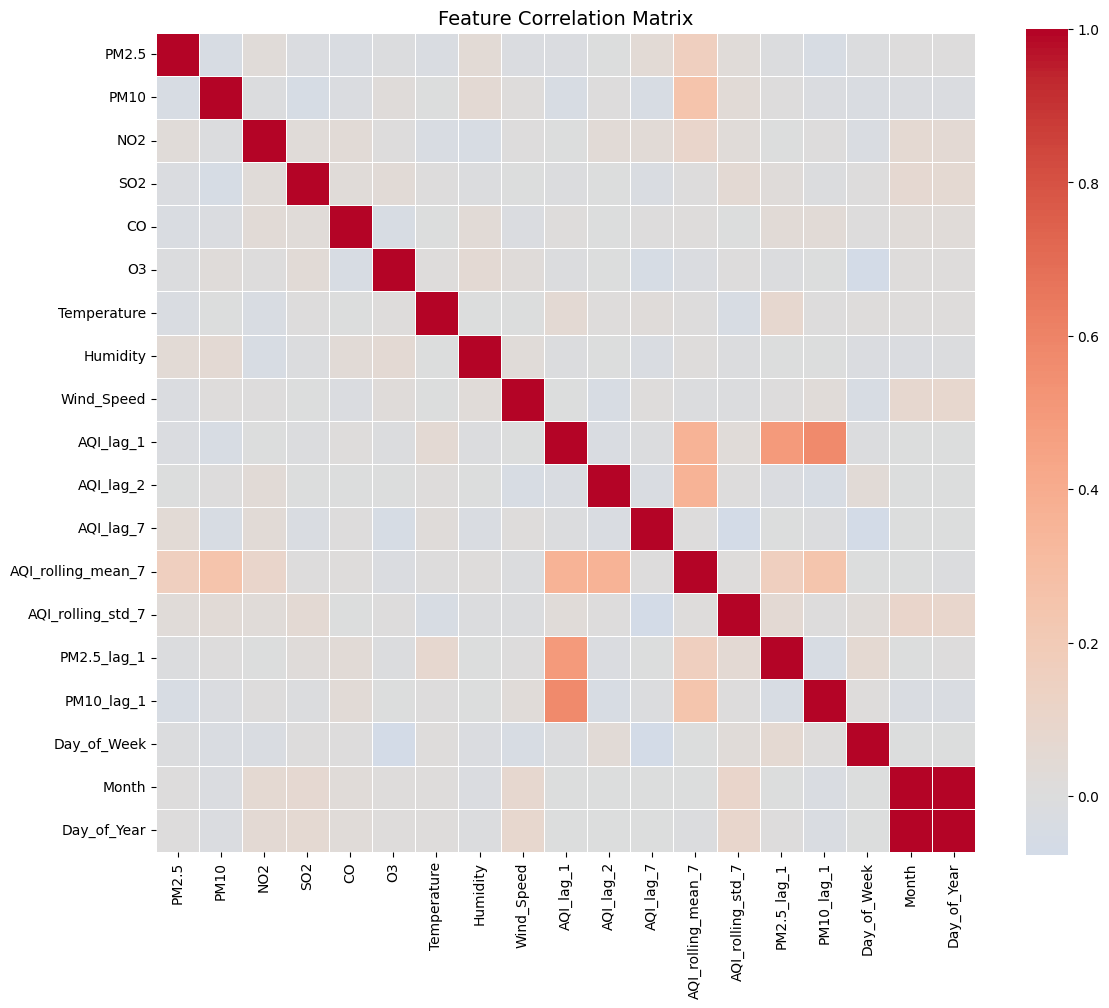


Highly correlated features (>0.7):
Month - Day_of_Year: 0.996


In [9]:
correlation_matrix = X_scaled.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append((correlation_matrix.columns[i],
                            correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]))

print("\nHighly correlated features (>0.7):")
for feat1, feat2, corr in high_corr:
    print(f"{feat1} - {feat2}: {corr:.3f}")

In [10]:
print("Dimensionality reduction-LDA")
y_binned = pd.cut(y, bins=5, labels=False)

lda = LDA(n_components=4)
X_lda = lda.fit_transform(X_scaled, y_binned)

print("\nLDA applied successfully")
print("Original dimensions:", X_scaled.shape[1])
print("Reduced dimensions:", X_lda.shape[1])
print("Dimension reduction:", round((1 - X_lda.shape[1]/X_scaled.shape[1])*100, 2), "%")

print("\nExplained variance ratio:", lda.explained_variance_ratio_)
print("Total variance explained:", sum(lda.explained_variance_ratio_))

print("\nJustification:")
print("-LDA used to handle multicollinearity among pollutants")
print("-Reduces high-dimensional feature space")
print("-Maintains class separability for AQI categories")

Dimensionality reduction-LDA

LDA applied successfully
Original dimensions: 19
Reduced dimensions: 4
Dimension reduction: 78.95 %

Explained variance ratio: [0.89706962 0.08329657 0.01215782 0.00747599]
Total variance explained: 0.9999999999999999

Justification:
-LDA used to handle multicollinearity among pollutants
-Reduces high-dimensional feature space
-Maintains class separability for AQI categories


In [11]:
split_index = int(len(X_lda) * 0.8)

X_train = X_lda[:split_index]
X_test = X_lda[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Train period:", df['Date'].iloc[:split_index].min(),"to",df['Date'].iloc[:split_index].max())
print("Test period:", df['Date'].iloc[split_index:].min(),"to",df['Date'].iloc[split_index:].max())


Training samples: 794
Testing samples: 199
Train period: 2021-01-08 00:00:00 to 2023-03-12 00:00:00
Test period: 2023-03-13 00:00:00 to 2023-09-27 00:00:00


In [12]:
print("ARIMA")
y_train_series = y_train.reset_index(drop=True)
y_test_series = y_test.reset_index(drop=True)

arima_model = ARIMA(y_train_series, order=(2, 1, 2))
arima_fitted = arima_model.fit()

y_pred_arima = arima_fitted.forecast(steps=len(y_test))

rmse_arima = np.sqrt(mean_squared_error(y_test_series, y_pred_arima))
mae_arima = mean_absolute_error(y_test_series, y_pred_arima)
r2_arima = r2_score(y_test_series, y_pred_arima)
mape_arima = np.mean(np.abs((y_test_series - y_pred_arima) / y_test_series)) * 100

print("\nARIMA Model Results:")
print("RMSE:", rmse_arima)
print("MAE:", mae_arima)
print("R² Score:", r2_arima)
print("MAPE:", mape_arima, "%")

ARIMA

ARIMA Model Results:
RMSE: 15.647692958552703
MAE: 12.835975414171962
R² Score: -0.0030478433076839284
MAPE: nan %


In [13]:
print("Random Forest regressor")
rf_model=RandomForestRegressor(n_estimators=100,max_depth=15,random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("\nRandom Forest Results:")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R² Score:", r2_rf)
print("MAPE:",mape_rf,"%")

Random Forest regressor

Random Forest Results:
RMSE: 9.364136276295772
MAE: 7.608772215808247
R² Score: 0.6407833422828444
MAPE: 14.919471157787203 %


In [14]:
print("Gradient Boosting regressor")
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                     max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
mape_gb = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

print("\nGradient Boosting Results:")
print("RMSE:", rmse_gb)
print("MAE:", mae_gb)
print("R² Score:", r2_gb)
print("MAPE:", mape_gb, "%")

Gradient Boosting regressor

Gradient Boosting Results:
RMSE: 9.361597168990548
MAE: 7.596120135036986
R² Score: 0.6409781207344277
MAPE: 14.843195166607629 %


In [15]:
print("Stacking Regressor")
base_models = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42))
]

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
mae_stack = mean_absolute_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)
mape_stack = np.mean(np.abs((y_test - y_pred_stack) / y_test)) * 100

print("\nStacking Regressor Results:")
print("RMSE:", rmse_stack)
print("MAE:", mae_stack)
print("R² Score:", r2_stack)
print("MAPE:", mape_stack, "%")

Stacking Regressor

Stacking Regressor Results:
RMSE: 9.077150987772065
MAE: 7.4209425586465025
R² Score: 0.662463971612553
MAPE: 14.643324881685443 %


In [16]:
print("Model evaluation and comparison")
results = pd.DataFrame({
    'Model': ['ARIMA', 'Random Forest', 'Gradient Boosting', 'Stacking'],
    'RMSE': [rmse_arima, rmse_rf, rmse_gb, rmse_stack],
    'MAE': [mae_arima, mae_rf, mae_gb, mae_stack],
    'R² Score': [r2_arima, r2_rf, r2_gb, r2_stack],
    'MAPE (%)': [mape_arima, mape_rf, mape_gb, mape_stack]
})

results = results.sort_values('R² Score', ascending=False)
print("\n", results.to_string(index=False))

best_model = results.iloc[0]['Model']
best_r2 = results.iloc[0]['R² Score']
print("\nBest Performing Model:", best_model)
print("Best R² Score:", best_r2)

Model evaluation and comparison

             Model      RMSE       MAE  R² Score  MAPE (%)
         Stacking  9.077151  7.420943  0.662464 14.643325
Gradient Boosting  9.361597  7.596120  0.640978 14.843195
    Random Forest  9.364136  7.608772  0.640783 14.919471
            ARIMA 15.647693 12.835975 -0.003048       NaN

Best Performing Model: Stacking
Best R² Score: 0.662463971612553


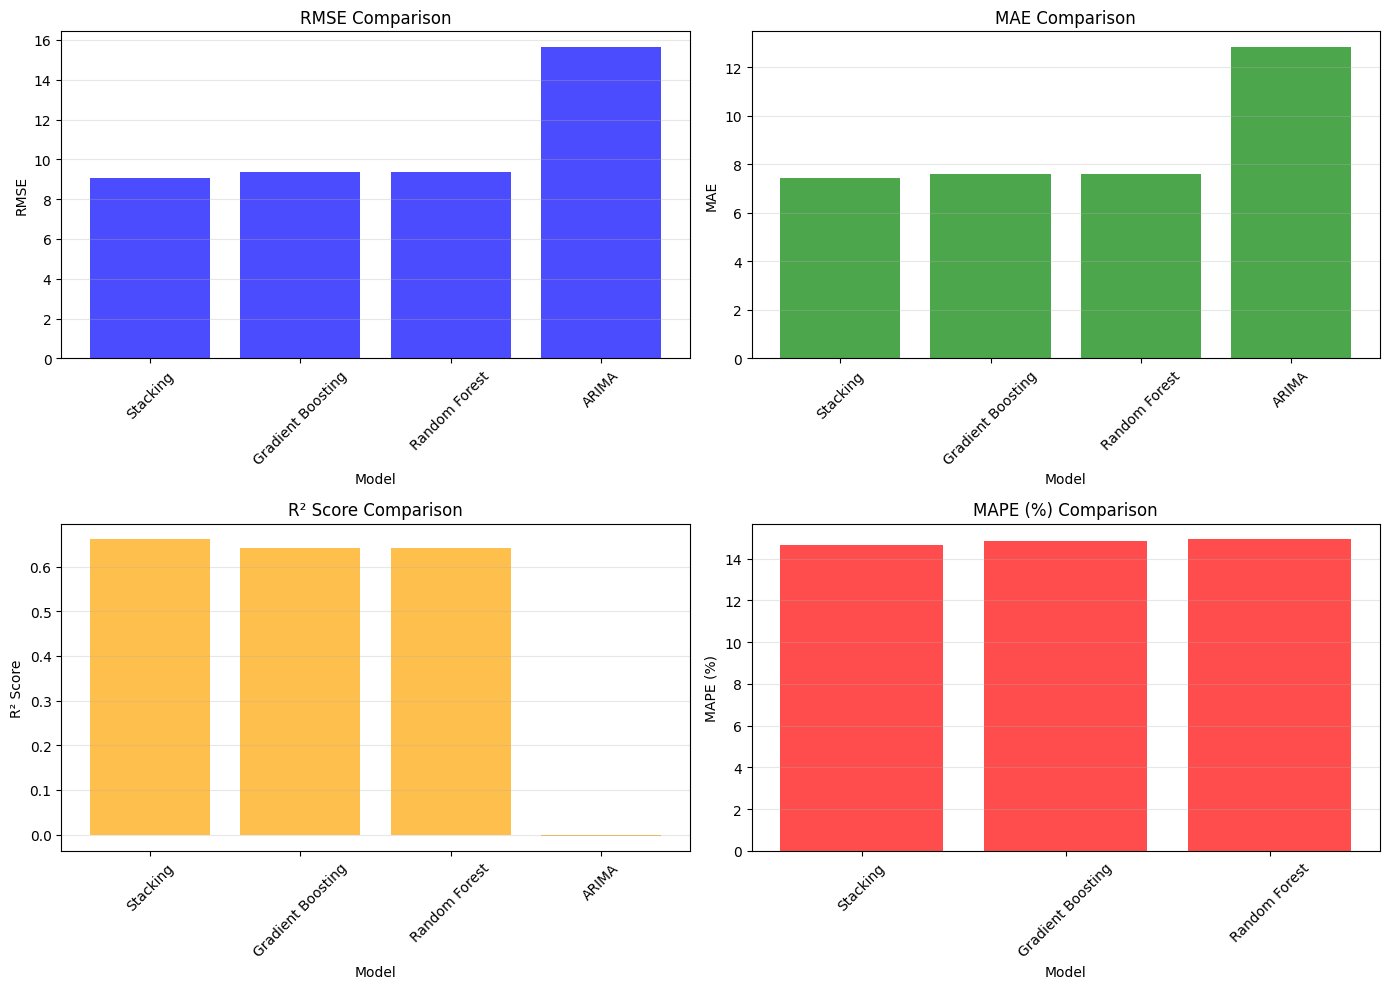

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = results['Model']
metrics = ['RMSE', 'MAE', 'R² Score', 'MAPE (%)']
colors = ['blue', 'green', 'orange', 'red']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    row = idx // 2
    col = idx % 2

    axes[row, col].bar(models, results[metric], color=color, alpha=0.7)
    axes[row, col].set_title(f'{metric} Comparison', fontsize=12)
    axes[row, col].set_xlabel('Model')
    axes[row, col].set_ylabel(metric)
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

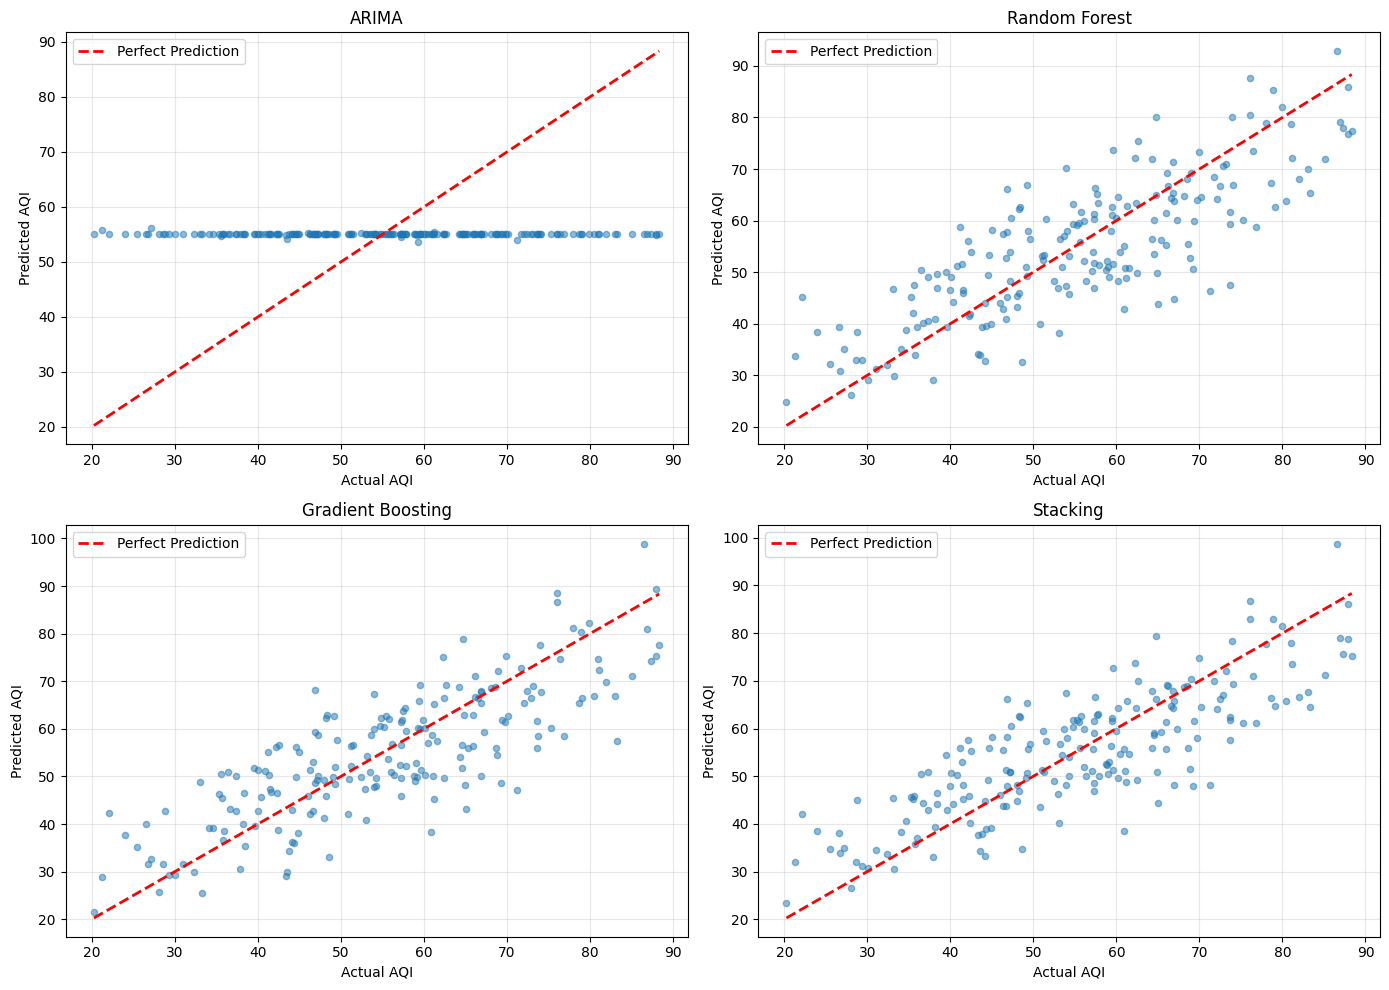

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

predictions = {
    'ARIMA': y_pred_arima,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'Stacking': y_pred_stack
}

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    row = idx // 2
    col = idx % 2

    axes[row, col].scatter(y_test, y_pred, alpha=0.5, s=20)
    axes[row, col].plot([y_test.min(), y_test.max()],
                        [y_test.min(), y_test.max()],
                        'r--', linewidth=2, label='Perfect Prediction')
    axes[row, col].set_title(f'{model_name}', fontsize=12)
    axes[row, col].set_xlabel('Actual AQI')
    axes[row, col].set_ylabel('Predicted AQI')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

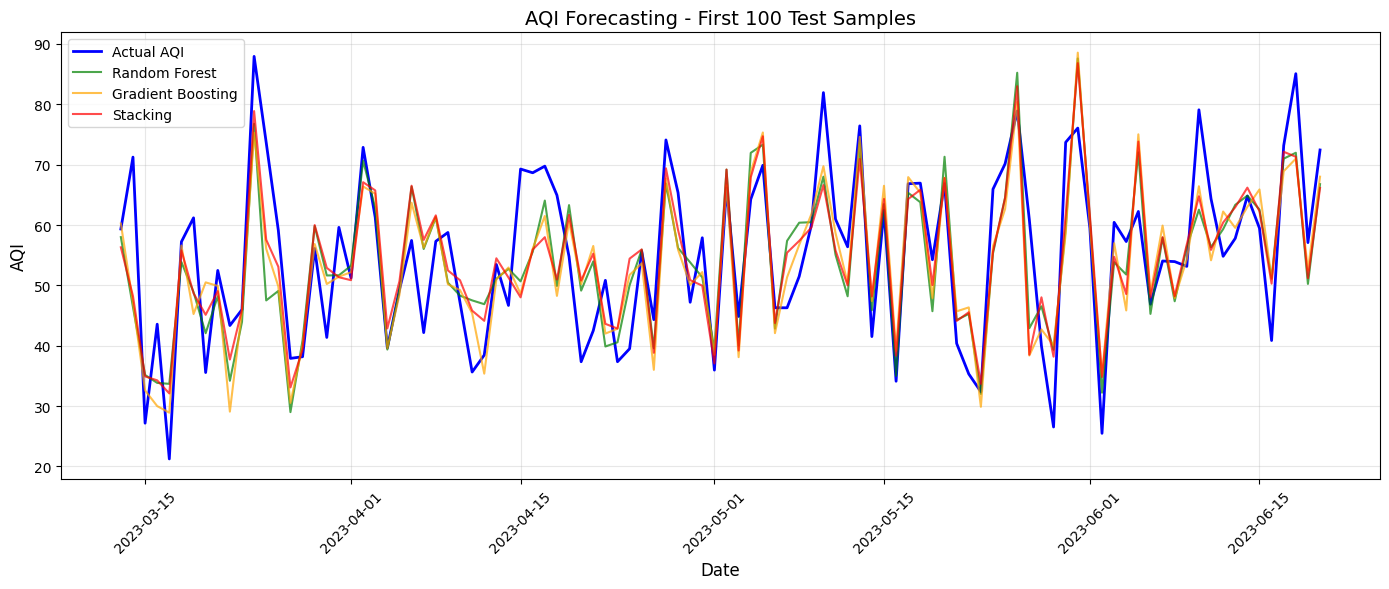

In [19]:
plt.figure(figsize=(14, 6))

test_dates = df['Date'].iloc[split_index:].values

plt.plot(test_dates[:100], y_test.values[:100],
         label='Actual AQI', linewidth=2, color='blue')
plt.plot(test_dates[:100], y_pred_rf[:100],
         label='Random Forest', linewidth=1.5, color='green', alpha=0.7)
plt.plot(test_dates[:100], y_pred_gb[:100],
         label='Gradient Boosting', linewidth=1.5, color='orange', alpha=0.7)
plt.plot(test_dates[:100], y_pred_stack[:100],
         label='Stacking', linewidth=1.5, color='red', alpha=0.7)

plt.xlabel('Date', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.title('AQI Forecasting - First 100 Test Samples', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()